In [3]:
import numpy as np
import torch
import fvdb
import tqdm

# A starting point from the previous notebook:
batch_size = 8
num_voxels_per_grid = [np.random.randint(1_000, 10_000) for _ in range(batch_size)]

# A list of randomly generated 3D indices for each grid in our batch in the range [-512, 512]
ijks = [torch.randint(-512, 512, (num_voxels_per_grid[i], 3), device='cuda') for i in range(batch_size)]

# ijks is currently a list of tensors, we need to convert it to a JaggedTensor
jagged_ijks = fvdb.JaggedTensor(ijks)

grid_batch = fvdb.GridBatch.from_ijk(
    jagged_ijks,  # We'll explain JaggedTensor in a moment…
    # Random, different voxel sizes for each grid in our batch
    voxel_sizes=[np.random.rand(3).tolist() for _ in range(batch_size)],
    # Random, different grid origins for each grid in our batch
    origins=[np.random.rand(3).tolist() for _ in range(batch_size)],
)

# 32 random features in a JaggedTensor
features = grid_batch.jagged_like(torch.randn(grid_batch.total_voxels, 32, device=grid_batch.device))

print(f"Grid has {grid_batch.grid_count} grids and {grid_batch.total_voxels} total voxels.")
print(f"Features shape: {features.jdata.shape}")

Grid has 8 grids and 43570 total voxels.
Features shape: torch.Size([43570, 32])


### Working with GridBatch and JaggedTensor Together

As you can tell from the previous notebook, the functionality for `GridBatch` and `JaggedTensor` are closely related to each other and it's often the case you want to perform operations that reference or affect both the grid and data at the same time. Many operations in `fvdb` accept both objects explicitly.

Both `GridBatch` and `JaggedTensor` can be moved to a device:
    
```python
    grid_batch = grid_batch.to(device)
    grid_batch = grid_batch.cuda()
    features = features.to(device)
```

##### Concatenation Operations

fVDB provides concatenation functions for both grids and data:

**`fvdb.jcat`** concatenates `JaggedTensor`s and has two modes:

1. The default mode, **dim=None**, concatenates along the **batch** dimension.  
If `J1` has **10** member grids in the batch and `J2` has **20** members in the batch, then `fvdb.jcat([J1,J2], dim=None)` will have **30** members.  
All input `JaggedTensor`s must have the same element shape.

2. Concatenating along **dimension 1** concatenates the **elements** (features) together.  
If `J1` has elements of shape **(3,)** and `J2` has elements of shape **(4,)**, then `fvdb.jcat([J1,J2], dim=1)` will produce a `JaggedTensor` with elements of shape **(7,)**.  
All input `JaggedTensor`s must have the same number of grids in the batch and number of voxels in each grid.

**`fvdb.gcat`** concatenates `GridBatch` objects along the batch dimension.

In [5]:
cat_batch = fvdb.jcat([features, features], dim=None)
cat_feat = fvdb.jcat([features, features], dim=1)

print(f"JaggedTensor with batch size {features.num_tensors}, element shape {list(features.jdata.shape[1:])}, total voxels {features.jdata.shape[0]}:")
print(f"\tjcat dim=None -> batch size {cat_batch.num_tensors}, element shape {list(cat_batch.jdata.shape[1:])}, total voxels {cat_batch.jdata.shape[0]}.")
print(f"\tjcat dim=1   -> batch size {cat_feat.num_tensors}, element shape {list(cat_feat.jdata.shape[1:])}, total voxels {cat_feat.jdata.shape[0]}.")

# gcat concatenates GridBatch objects along the batch dimension
grid_a = fvdb.GridBatch.from_ijk(fvdb.JaggedTensor(ijks[:4]))
grid_b = fvdb.GridBatch.from_ijk(fvdb.JaggedTensor(ijks[4:]))
grid_combined = fvdb.gcat([grid_a, grid_b])

print(f"\ngcat: grid_a ({grid_a.grid_count} grids) + grid_b ({grid_b.grid_count} grids) -> grid_combined ({grid_combined.grid_count} grids, {grid_combined.total_voxels} total voxels).")


JaggedTensor with batch size 8, element shape [32], total voxels 43570:
	jcat dim=None -> batch size 16, element shape [32], total voxels 87140.
	jcat dim=1   -> batch size 8, element shape [64], total voxels 43570.

gcat: grid_a (4 grids) + grid_b (4 grids) -> grid_combined (8 grids, 43570 total voxels).


####  NN Modules

`fvdb.nn` provides specialized sparse-grid-aware neural network modules.

* `fvdb.nn.SparseConv3d`: sparse 3D convolution
* `fvdb.nn.SparseConvTranspose3d`: sparse 3D transposed convolution
* `fvdb.nn.BatchNorm`: batch normalization for sparse data
* `fvdb.nn.GroupNorm`: group normalization for sparse data
* `fvdb.nn.AvgPool` / `fvdb.nn.MaxPool`: sparse pooling
* `fvdb.nn.UpsamplingNearest`: sparse nearest-neighbor upsampling

For pointwise operations like fully-connected layers and activations, use standard `torch.nn` modules directly on the `.jdata` of a `JaggedTensor`:

In [6]:
linear = torch.nn.Sequential(torch.nn.Linear(32, 64), torch.nn.LeakyReLU()).to('cuda')

out_data = grid_batch.jagged_like(linear(features.jdata))

print(f"Linear layer took input of element size {features.jdata.shape[1]} and output element size {out_data.jdata.shape[1]}.")

Linear layer took input of element size 32 and output element size 64.


In this simple example we ran a `JaggedTensor`'s data through a fully-connected layer to produce new features, then wrapped the result back into a `JaggedTensor` using `grid.jagged_like()`.

&#x1F4A1; It's worth noting that pointwise operations (like `Linear`) don't change the topology of the grids in any way -- they only produce new data.  The same `GridBatch` can be reused with any number of `JaggedTensor`s that share its structure.


In practice, in the course of running grid operators in a deep neural network, it is often the case that there are several `JaggedTensor`s which are produced that correspond to a single `GridBatch`.  

Operations that don't alter the topology of the grid (like pointwise operations) produce new `JaggedTensor` data that can be associated with the original `GridBatch`.  Only operations like convolution with stride or pooling produce a new `GridBatch` with a different topology.

### Training the Simple Network Again

Let's return to the simple network which classifies the voxels in a grid as being inside or outside of a sphere.  At this point, you should have a good understanding of how all the pieces fit together in this example to train the network.

In [8]:
# DataSet that produces random grids centered at 0, 0, 0 worldspace with voxel sizes (0.005, 0.005, 0.005)
from torch.utils.data import Dataset
class RandomGridsDataset(Dataset):
    def __init__(self, batch_size):
        self.batch_size = batch_size
    def __len__(self):
        return 100
    def __getitem__(self, idx):
        ijks = [torch.randint(-200, 200, (np.random.randint(5_000, 50_000), 3), device='cuda') for i in range(self.batch_size)]
        jagged_ijks = fvdb.JaggedTensor(ijks)
        grid = fvdb.GridBatch.from_ijk(jagged_ijks, voxel_sizes=0.005)
        # features are the world-space coordinates of the voxels
        features = grid.voxel_to_world(grid.ijk.float())
        return grid, features

# Define model using standard PyTorch modules for pointwise operations
class Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.fc0 = torch.nn.Linear(3, 16)
        self.fc1 = torch.nn.Linear(3, 16)
        self.fc2 = torch.nn.Linear(32, 32)
        self.fc3 = torch.nn.Linear(32, 1)
        self.relu = torch.nn.LeakyReLU()
        self.sigmoid = torch.nn.Sigmoid()
    def forward(self, features):
        # Pointwise operations on the flat data (.jdata) of a JaggedTensor
        x = self.relu(torch.cat([self.fc0(features.jdata), self.fc1(features.jdata)], dim=1))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x


# Data
dataset = RandomGridsDataset(batch_size)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, collate_fn=lambda x: x[0])

# Model, Loss, Optimizer
model = Model().to('cuda')

loss = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=.001)

epochs = 10
with tqdm.tqdm(total=epochs) as pbar:
    for epoch in range(epochs):
        for i, (grid, features) in enumerate(dataloader):
            optimizer.zero_grad()
            output = model(features)
            # Whether each voxel is inside or outside of the unit sphere centered at the origin
            dist = torch.sqrt(torch.sum(grid.voxel_to_world(grid.ijk.float()).jdata ** 2, dim=1))
            target = (dist < 1).float()
            l = loss(output, target[:, None])
            l.backward()
            optimizer.step()
            pbar.set_description(f"Epoch {epoch}, batch {i}, loss {l.item()}")
        pbar.update(1)


Epoch 9, batch 99, loss 0.037200622260570526: 100%|██████████| 10/10 [00:10<00:00,  1.01s/it]


Let's visualize a sample of predictions from the network to see how well it's doing.

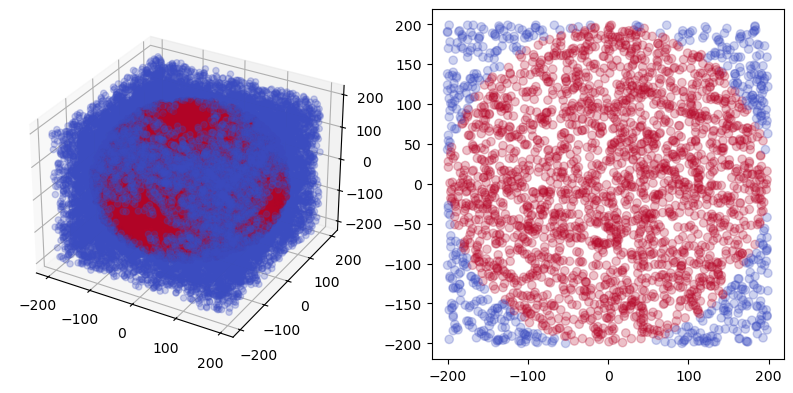

In [9]:
import matplotlib.pyplot as plt

test_grid, test_features = next(iter(dataloader))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(2,2,1, projection='3d')

model.eval()
pred = model(test_features)

ijks_0 = test_grid.ijk.jdata[test_grid.jidx==0].detach().cpu().numpy()
pred_0 = pred[test_grid.jidx==0].detach().cpu()

preds_in_sphere = ijks_0[torch.round(pred_0)[:,-1] == 1]

ax.scatter3D(ijks_0[:, 0], ijks_0[:, 1], ijks_0[:, 2], marker = 'o', c = torch.round(pred_0), cmap='coolwarm', alpha =0.25)

# Also plot a 2D slice to make it easier to see
pred_0 = pred_0[((ijks_0[:, 2]>-20) & (ijks_0[:, 2]<20))]

ijks_0 = ijks_0[((ijks_0[:, 2]>-20) & (ijks_0[:, 2]<20))]

ax = fig.add_subplot(2,2,2)
ax.scatter(ijks_0[:, 0], ijks_0[:, 1], c=torch.round(pred_0), marker = 'o', cmap='coolwarm', alpha=0.25)
fig.show()